# 循环神经网络 Recurrent Neural Network (RNN)

是一种专门处理序列数据的神经网络。RNN具有“**循环**”结构，能够处理和记住前面时间步的信息，使其特别适用于时间序列数据或有时序依赖的任务。

> 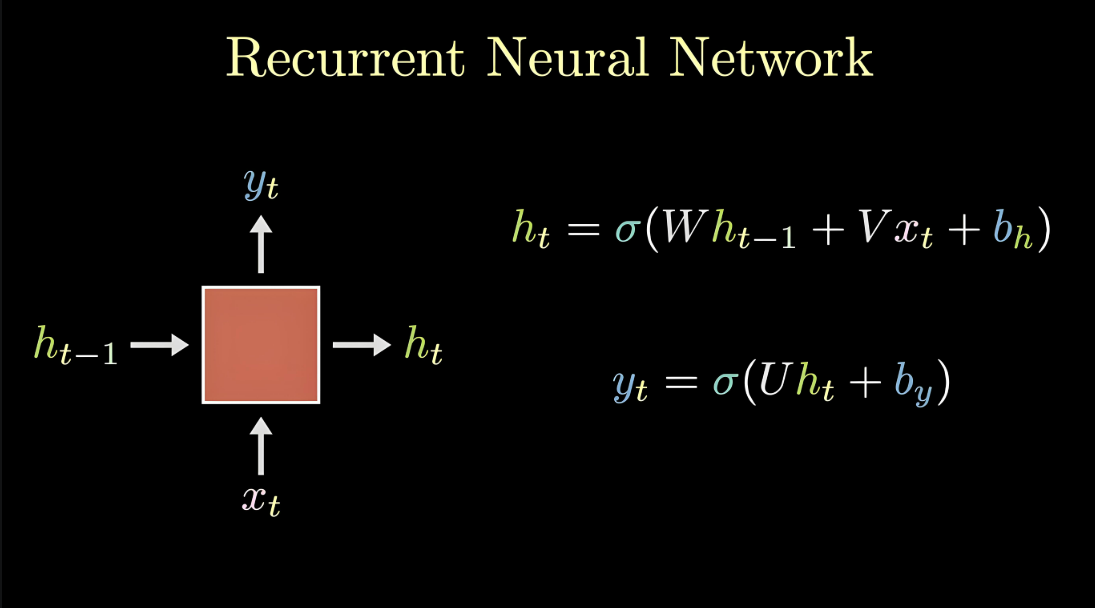

## 词嵌入层：单词索引->向量

> 在 **RNN（Recurrent Neural Network）** 中，**词嵌入层（Word Embedding Layer）** 是处理自然语言数据的关键组成部分。它将输入的离散单词（通常是词汇表中的索引）转换为连续的、低维的向量表示，从而使得神经网络能够理解和处理这些词汇的语义信息。

> 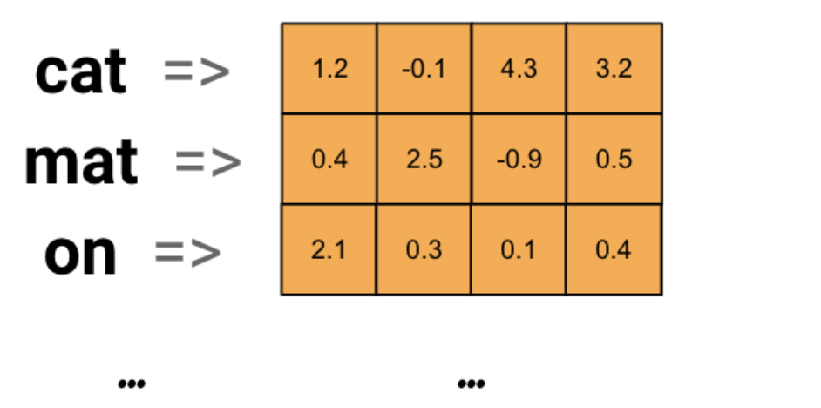

### 词嵌入层作用

词嵌入层的主要目的是**将每个词映射为一个固定长度的向量（将文本转换为向量）**，这些向量能够捕捉词与词之间的语义关系。

传统的文本表示方法（如one-hot编码）无法反映单词之间的相似性，因为在one-hot编码中，每个单词都被表示为一个**高维稀疏向量**，而词嵌入通过**低维稠密向量**表示单词，能够更好地捕捉词汇之间的语义相似性。

词嵌入层首先会根据输入的词的数量构建一个**词向量矩阵**，例如: 我们有 100 个词，每个词希望转换成 128 维度的向量，那么构建的矩阵形状即为: 100*128，输入的每个词都对应了一个该矩阵中的一个向量。

这些词向量作为RNN的输入，RNN处理它们并根据上下文生成一个序列的输出。

In [4]:
import torch
import jieba
import torch.nn as nn

text = '北京冬奥的进度条已经过半，不少外国运动员在完成自己的比赛后踏上归途。'
words = jieba.lcut(text)
print(f'分词：{words}')

# 词表大小，词向量维度
embed = nn.Embedding(len(words),4)
for i, word in enumerate(words):
    # print(i, word)
    # 把词索引的张量形式转成词向量
    word_vec = embed(torch.tensor(i))
    print(f'词：{word},词向量：{word_vec}')

分词：['北京', '冬奥', '的', '进度条', '已经', '过半', '，', '不少', '外国', '运动员', '在', '完成', '自己', '的', '比赛', '后', '踏上', '归途', '。']
词：北京,词向量：tensor([ 0.3388, -0.2631,  0.4635,  0.4899], grad_fn=<EmbeddingBackward0>)
词：冬奥,词向量：tensor([ 0.4285, -0.1283,  0.5523,  0.1300], grad_fn=<EmbeddingBackward0>)
词：的,词向量：tensor([-1.1351,  0.2042, -0.2329,  1.1471], grad_fn=<EmbeddingBackward0>)
词：进度条,词向量：tensor([-0.9087,  1.6818,  1.3631,  1.5509], grad_fn=<EmbeddingBackward0>)
词：已经,词向量：tensor([ 0.1462,  0.4889, -0.7292, -0.8983], grad_fn=<EmbeddingBackward0>)
词：过半,词向量：tensor([-1.5759, -0.2337, -0.1891, -1.1695], grad_fn=<EmbeddingBackward0>)
词：，,词向量：tensor([ 0.1182, -0.1577,  0.4538, -0.1039], grad_fn=<EmbeddingBackward0>)
词：不少,词向量：tensor([ 1.0878, -1.3145, -0.4172,  1.8624], grad_fn=<EmbeddingBackward0>)
词：外国,词向量：tensor([ 0.3062, -0.2912, -0.1348,  0.1327], grad_fn=<EmbeddingBackward0>)
词：运动员,词向量：tensor([-1.9184, -0.0131, -0.3524, -1.4129], grad_fn=<EmbeddingBackward0>)
词：在,词向量：tensor([-0.9203, -0.6270,  0.0333,  1.

## RNN循环层

每一次的输入都会包含两个值：**上一个时间步的隐藏状态、当前状态的输入值x**

每一次的输出都会包含两个值：**输出当前时间步的隐藏状态、当前时间步的预测结果y**

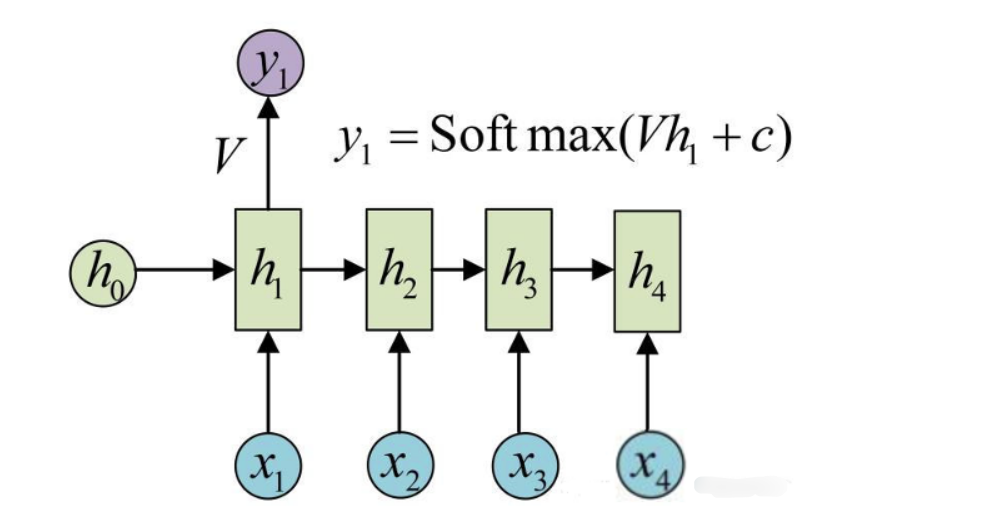

In [5]:
# 1词向量维度：每次看到的画面细节数
# 2隐藏状态向量维度：能记住原来的剧情信息多少
# 3隐藏层数量(默认是1)：大脑解读的深度
rnn = nn.RNN(input_size=128, hidden_size=256, num_layers=1)

# 每个句子词的个数，句子的数量，词向量的维度
x = torch.randn(size = (5, 32, 128))

# 隐藏层层数，句子数量，隐藏层向量维度
h0 = torch.randn(size = (1, 32, 256))

# 本次输入，上一次隐藏状态
# output：每个时间步的输出，包含所有时间步的隐藏状态
# h1：最后一个时间步的隐藏状态
output, h1 = rnn(x, h0)
print(f'output:{output.shape},h1:{h1.shape}')

output:torch.Size([5, 32, 256]),h1:torch.Size([1, 32, 256])
